## 0. Setup

Place `session4_baseline.pt` in the same directory as this notebook. In Google Colab, upload the file to `/content`, or define the environment variable `SESSION4_CHECKPOINT` with its full path.

> **Security note:** a PyTorch `.pt` file can use Python serialization. Load only checkpoints that you created yourself or obtained from a trusted source.

In [9]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from torchvision.models.segmentation import lraspp_mobilenet_v3_large

SEED = 17
IMAGE_SIZE = (128, 128)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch={torch.__version__} | device={device}')


torch=2.11.0+cpu | device=cpu


In [10]:
from pathlib import Path
import os

print("Directorio de trabajo:", Path.cwd())
print("¿Existe /content?:", Path("/content").exists())

if Path("/content").exists():
    print("\nContenido exacto de /content:")
    for nombre in os.listdir("/content"):
        print(repr(nombre))

Directorio de trabajo: /content
¿Existe /content?: True

Contenido exacto de /content:
'.config'
'session4_baseline.pt'
'.ipynb_checkpoints'
'sample_data'


In [14]:
from pathlib import Path
import torch

checkpoint_path = Path("session4_baseline.pt")

print("Ruta:", checkpoint_path)
print("¿Existe?:", checkpoint_path.is_file())

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"No se encontró el archivo en: {checkpoint_path}"
    )

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint cargado correctamente")
print("Claves disponibles:")

for key in checkpoint.keys():
    print(" -", key)


Ruta: session4_baseline.pt
¿Existe?: True
Checkpoint cargado correctamente
Claves disponibles:
 - artifact_version
 - seed
 - image_size
 - epochs
 - train_indices
 - val_indices
 - mean_train_loss
 - metrics
 - model_state_dict
 - validation_images
 - validation_targets
 - validation_predictions
 - validation_logits


In [15]:
# The artifact already contains the complete 24-image validation handoff.
required_keys = {
    'model_state_dict',
    'validation_images',
    'validation_targets',
    'validation_logits',
}
missing_keys = required_keys.difference(checkpoint)
if missing_keys:
    raise KeyError(f'Missing checkpoint keys: {sorted(missing_keys)}')

images = checkpoint['validation_images'].detach().cpu()
targets = checkpoint['validation_targets'].detach().cpu().long()
logits = checkpoint['validation_logits'].detach().cpu()
probabilities = logits.softmax(dim=1)
predictions = probabilities.argmax(dim=1)
pet_confidence = probabilities[:, 1]
val_indices = checkpoint.get('val_indices', list(range(len(images))))

assert images.shape == (24, 3, 128, 128)
assert targets.shape == predictions.shape == pet_confidence.shape == (24, 128, 128)
assert logits.shape == (24, 2, 128, 128)
assert set(torch.unique(targets).tolist()) <= {0, 1, IGNORE_INDEX}

saved_predictions = checkpoint.get('validation_predictions')
if saved_predictions is not None:
    assert torch.equal(predictions, saved_predictions.cpu())

print('Validation tensors loaded successfully:')
print('  images:', tuple(images.shape))
print('  targets:', tuple(targets.shape))
print('  logits:', tuple(logits.shape))
print('  validation examples:', len(val_indices))


Validation tensors loaded successfully:
  images: (24, 3, 128, 128)
  targets: (24, 128, 128)
  logits: (24, 2, 128, 128)
  validation examples: 24


## 1. Use the shared Session 4 baseline

For this evaluation notebook, the preferred route is to use the saved validation logits and targets directly. This avoids accidentally evaluating a shuffled training batch and reproduces the exact 24-example validation handoff generated in Session 4.

In [16]:
print('Session 4 training summary:')
print('  seed:', checkpoint.get('seed'))
print('  epochs:', checkpoint.get('epochs'))
print('  mean training loss:', checkpoint.get('mean_train_loss'))
print('  saved validation metrics:', checkpoint.get('metrics'))

assert len(images) == 24
assert predictions.shape == targets.shape == pet_confidence.shape


Session 4 training summary:
  seed: 17
  epochs: 1
  mean training loss: 0.5086636319756508
  saved validation metrics: {'loss': 0.36764344863452103, 'pixel_accuracy': 0.8504345352393144, 'pet_iou': 0.6360615793554103}


## 2. Exercise E1 — report dataset-level metrics

Complete the confusion-matrix accumulation. Rows are true classes and columns are predicted classes. Accumulate all valid pixels across all 24 examples **before** calculating accuracy and IoU.

In [17]:
# TODO: return a 2x2 confusion matrix, excluding every target == IGNORE_INDEX
def confusion_matrix(targets, predictions, num_classes=2):
    """Accumulate a [true, predicted] confusion matrix over every valid pixel in the batch."""
    valid = targets != IGNORE_INDEX
    true_valid = targets[valid].to(torch.int64)
    pred_valid = predictions[valid].to(torch.int64)
    flat_indices = true_valid * num_classes + pred_valid
    counts = torch.bincount(flat_indices, minlength=num_classes * num_classes)
    return counts.reshape(num_classes, num_classes)

confusion = confusion_matrix(targets, predictions)
valid_pixels = confusion.sum().item()
true_positive = torch.diag(confusion).to(torch.float64)
accuracy = (true_positive.sum() / valid_pixels).item()
union = confusion.sum(dim=1) + confusion.sum(dim=0) - true_positive
class_iou = torch.where(union > 0, true_positive / union, torch.zeros_like(union))

print('rows=true, columns=predicted')
print(confusion)
print(f'valid pixels: {valid_pixels} of {targets.numel()}')
print(f'pixel accuracy: {accuracy:.3f}')
for name, iou in zip(CLASS_NAMES, class_iou.tolist()):
    print(f'{name} IoU: {iou:.3f}')


rows=true, columns=predicted
tensor([[207061,  46596],
        [  5980,  91888]])
valid pixels: 351525 of 393216
pixel accuracy: 0.850
background IoU: 0.798
pet IoU: 0.636


The value above is a dataset report: every valid pixel gets one vote. We do **not** average 24 per-image IoUs, because that would weight a tiny pet and a large pet equally.

## 3. Choose three cases by rule

Rule: select the lowest pet-IoU image, then the median and highest pet-IoU images from the remaining examples. This gives one difficult case and two contrasts without cherry-picking by appearance.

In [18]:
def pet_iou(target, prediction):
    valid = target != IGNORE_INDEX
    truth_pet, predicted_pet = (target == 1) & valid, (prediction == 1) & valid
    union = (truth_pet | predicted_pet).sum().item()
    return (truth_pet & predicted_pet).sum().item() / union if union else np.nan

per_image_iou = np.array([pet_iou(target, prediction) for target, prediction in zip(targets, predictions)])
ordered = np.argsort(np.nan_to_num(per_image_iou, nan=2.0))
low_index = int(ordered[0])
remaining = [int(index) for index in ordered if int(index) != low_index]
chosen_indices = [low_index, remaining[len(remaining) // 2], remaining[-1]]
for index in chosen_indices:
    print(f'pet IoU = {per_image_iou[index]:.3f}')
assert len(set(chosen_indices)) == 3

pet IoU = 0.219
pet IoU = 0.719
pet IoU = 0.962


## 4. Exercise E2 — make aligned visual evidence

Complete the plotting function, then call it for the lowest-pet-IoU case. All five panels use the same `128 × 128` pixel coordinates: original image, ground truth, prediction, pet confidence, and an alpha overlay. Gray ground-truth pixels are ignored borders, not a third class.

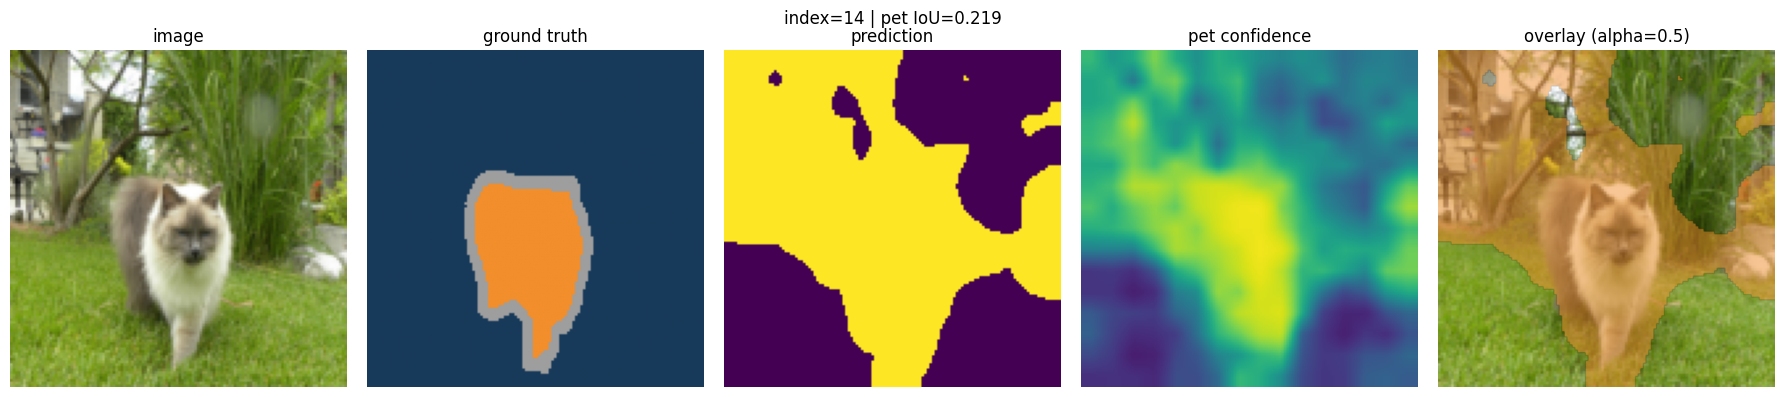

In [19]:
# TODO: complete the five-panel visualization; do not resize panels independently
TARGET_DISPLAY_CMAP = ListedColormap(["#183a5a", "#f28e2b", "#9e9e9e"])  # background, pet, ignored border
OVERLAY_CMAP = ListedColormap(["none", "#f28e2b"])


def image_for_display(image_tensor):
    mean = torch.tensor(MEAN)[:, None, None]
    std = torch.tensor(STD)[:, None, None]
    return (image_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def target_for_display(target_tensor):
    display = target_tensor.clone()
    display[target_tensor == IGNORE_INDEX] = 2
    return display


def show_five_panels(index, alpha=0.5):
    image = image_for_display(images[index])
    target = target_for_display(targets[index])
    prediction = predictions[index]
    confidence = pet_confidence[index]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(image)
    axes[0].set_title("image")
    axes[1].imshow(target, cmap=TARGET_DISPLAY_CMAP, vmin=0, vmax=2)
    axes[1].set_title("ground truth")
    axes[2].imshow(prediction, cmap="viridis", vmin=0, vmax=1)
    axes[2].set_title("prediction")
    axes[3].imshow(confidence, cmap="viridis", vmin=0, vmax=1)
    axes[3].set_title("pet confidence")
    axes[4].imshow(image)
    axes[4].imshow(prediction, cmap=OVERLAY_CMAP, vmin=0, vmax=1, alpha=alpha)
    axes[4].set_title(f"overlay (alpha={alpha})")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"index={index} | pet IoU={per_image_iou[index]:.3f}")
    plt.tight_layout()


show_five_panels(chosen_indices[0])


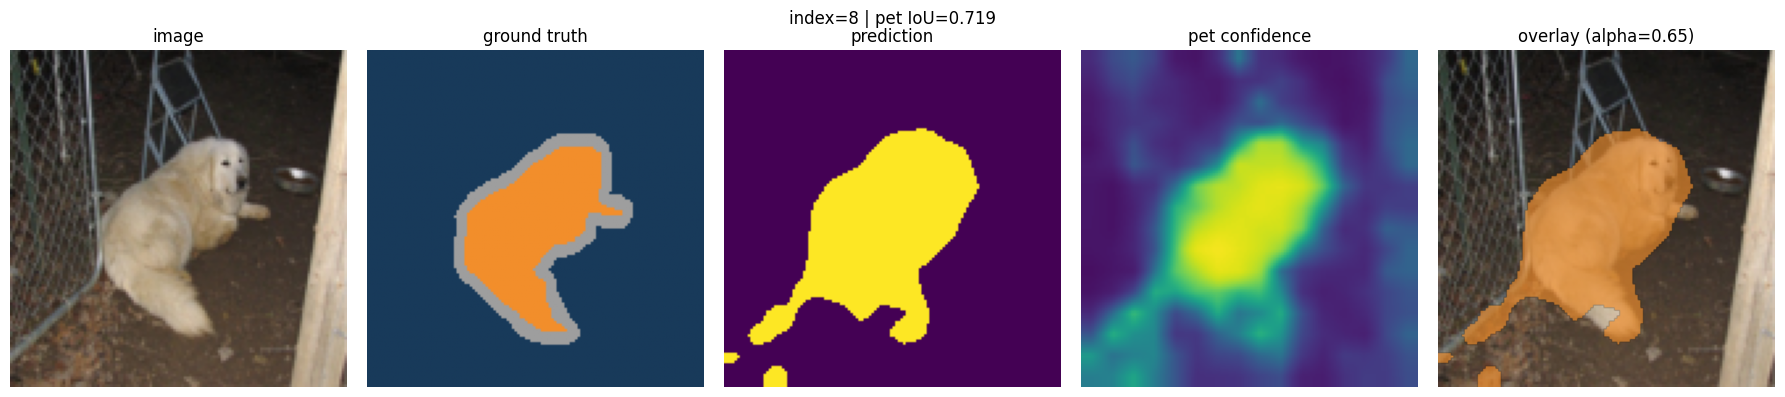

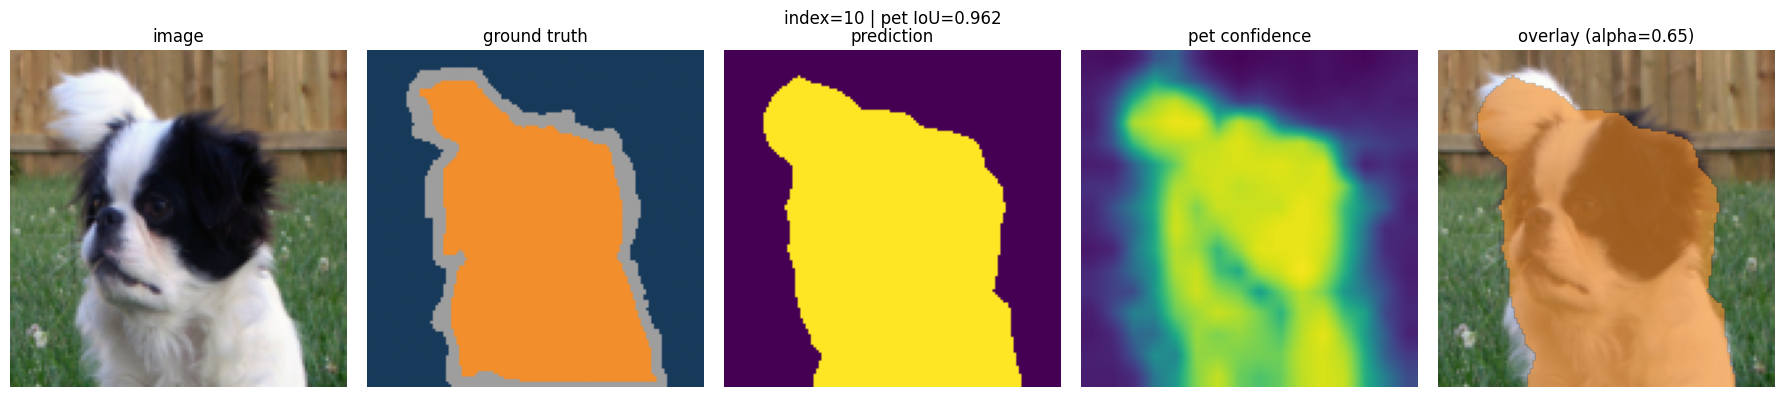

In [20]:
# Compare the other two rule-selected cases. Changing alpha only changes the display.
show_five_panels(chosen_indices[1], alpha=0.65)
show_five_panels(chosen_indices[2], alpha=0.65)

## 5. Optional — reconstruct the model for new images

The stored validation tensors are enough for Exercises E1 and E2. To predict a new image, recreate the same LR-ASPP architecture, load `model_state_dict`, apply the same resize and ImageNet normalization, and run inference.

In [21]:
model = lraspp_mobilenet_v3_large(
    weights=None,
    weights_backbone=None,
    num_classes=2,
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

def predict_pil_image(pil_image):
    """Return a 128x128 pet mask and pet-confidence map for one PIL image."""
    resized = TF.resize(
        pil_image.convert('RGB'),
        IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )
    input_tensor = TF.normalize(
        TF.to_tensor(resized), mean=MEAN, std=STD
    ).unsqueeze(0).to(device)

    with torch.inference_mode():
        new_logits = model(input_tensor)['out']
        new_probability = new_logits.softmax(dim=1)[:, 1]
        new_prediction = new_logits.argmax(dim=1)

    return new_prediction[0].cpu(), new_probability[0].cpu()

print('Model reconstructed successfully and ready for new images.')
# Example:
# new_image = Image.open('my_pet.jpg')
# new_mask, new_confidence = predict_pil_image(new_image)


Model reconstructed successfully and ready for new images.
